<a href="https://colab.research.google.com/github/AtifShams/ML_Projects/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objective:**

Build a machine learning model to predict whether a customer will churn based on demographic and service-related features.

In [1]:
import kagglehub
import pandas as pd

# **Data Loading**

In [2]:
path = kagglehub.dataset_download('blastchar/telco-customer-churn')
csv_file = f'{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(csv_file, encoding = 'Windows-1252')
print(df.info())

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract      

# **Data Preprocessing**

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **Data Encoding**

In [4]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
y = df['Churn']
x = df.drop(columns= ['Churn','customerID'])
x = pd.get_dummies(x, drop_first=True)

for col in x.select_dtypes(include='bool').columns:
    x[col] = x[col].astype(int)

print(x.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   PhoneService_Yes                       7043 non-null   int64  
 8   MultipleLines_No phone service         7043 non-null   int64  
 9   MultipleLines_Yes                      7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   int64  
 11  Inte

# **Train-Test Split & Feature Scaling**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()


x_train, x_test, y_train, y_test  = train_test_split(x, y, test_size=0.2, random_state=42)

x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

# **Model Training**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(x_train, y_train)


LogisticRegression()

# **Model Accuracy**

In [7]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.82


# **Test Vs Train Accuracy**

In [8]:
Train_acc = model.score(x_train, y_train)
Test_acc = model.score(x_test, y_test)
print(f'Train Accuracy: {Train_acc:.2f}')
print(f'Test Accuracy: {Test_acc:.2f}')

Train Accuracy: 0.80
Test Accuracy: 0.82


# **Confusion Matrix**

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[933 103]
 [151 222]]


# **Visualization of Confusion Matrix**

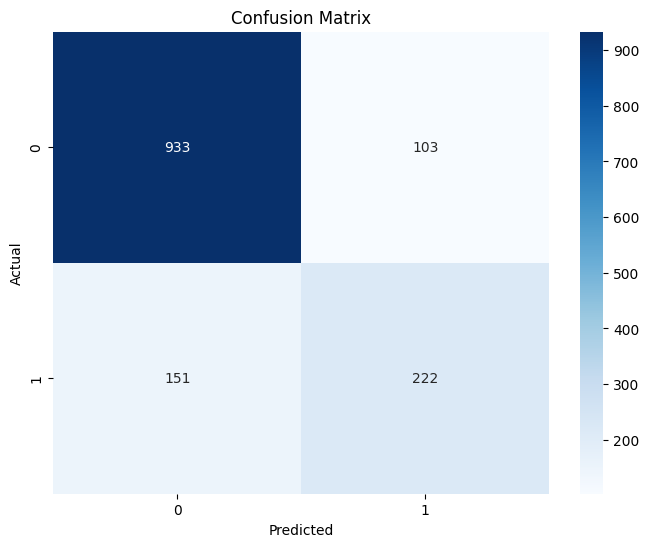

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Model Evaluation**

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



# **Coefficient Interpretation**

In [12]:
model = model.fit(x_train, y_train)
model.coef_
coef_df = pd.DataFrame(model.coef_[0], index=x.columns, columns=['Coefficient'])
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print(coef_df)

                                       Coefficient
TotalCharges                              0.627137
InternetService_Fiber optic               0.622950
StreamingMovies_Yes                       0.230364
StreamingTV_Yes                           0.180316
MultipleLines_Yes                         0.168662
PaperlessBilling_Yes                      0.163692
PaymentMethod_Electronic check            0.150779
SeniorCitizen                             0.058427
MultipleLines_No phone service            0.034680
DeviceProtection_Yes                      0.028529
Partner_Yes                               0.027103
PaymentMethod_Mailed check               -0.013849
gender_Male                              -0.025598
PhoneService_Yes                         -0.034680
PaymentMethod_Credit card (automatic)    -0.036861
OnlineBackup_Yes                         -0.044399
Dependents_Yes                           -0.073852
OnlineBackup_No internet service         -0.075657
InternetService_No             

Text(0, 0.5, 'Coefficient')

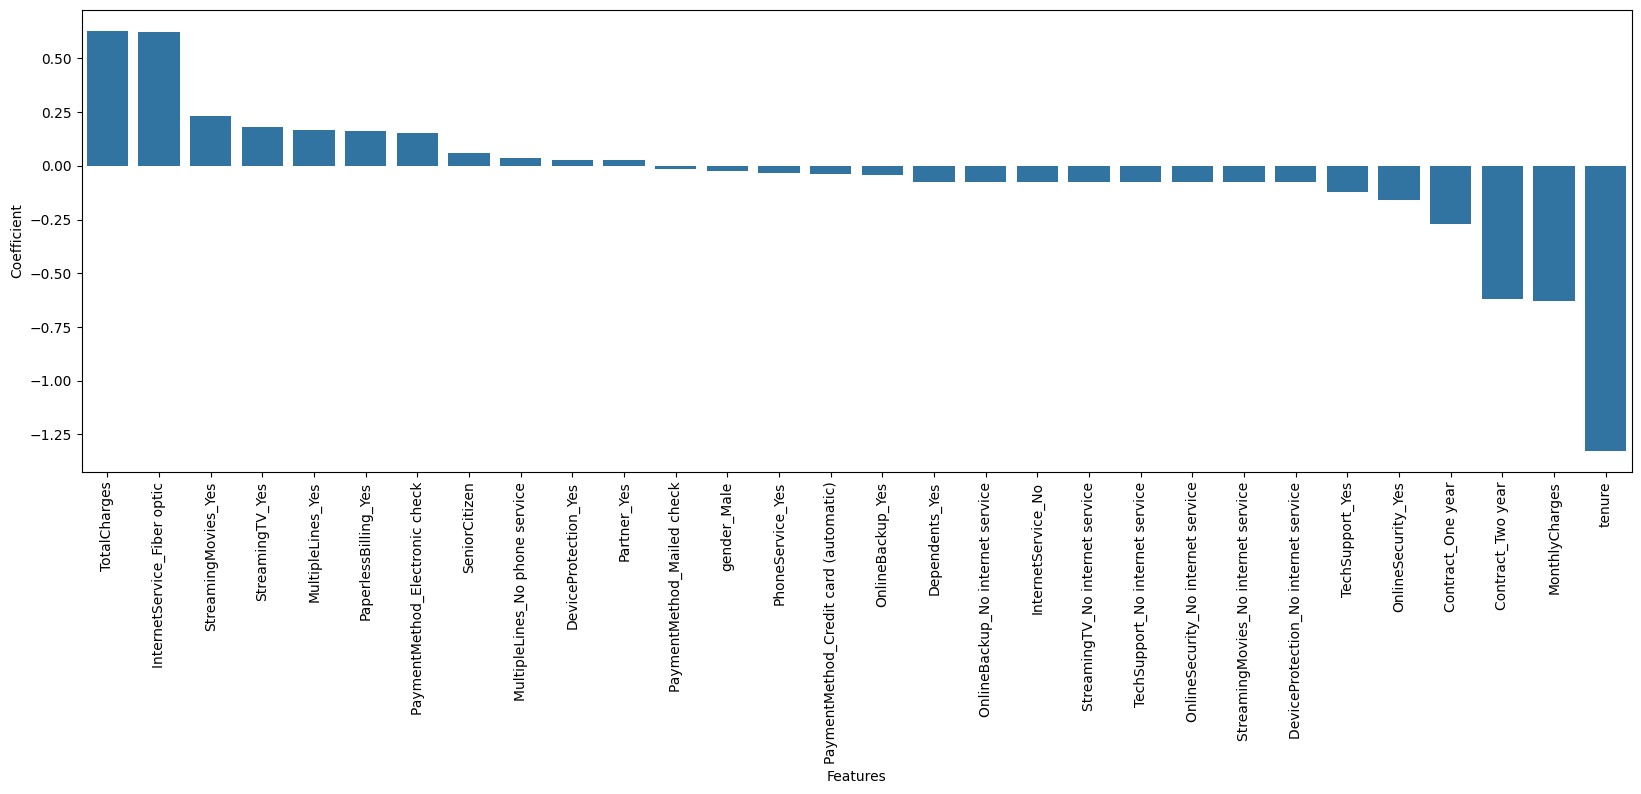

In [13]:
plt.figure(figsize=(20, 6))
sns.barplot(x=coef_df.index, y=coef_df['Coefficient'])
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Coefficient')

In [14]:
from sklearn.metrics import roc_curve, auc

probs = model.predict_proba(x_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8620040473257631


Text(0.5, 1.0, 'Receiver Operating Characteristic (ROC) Curve')

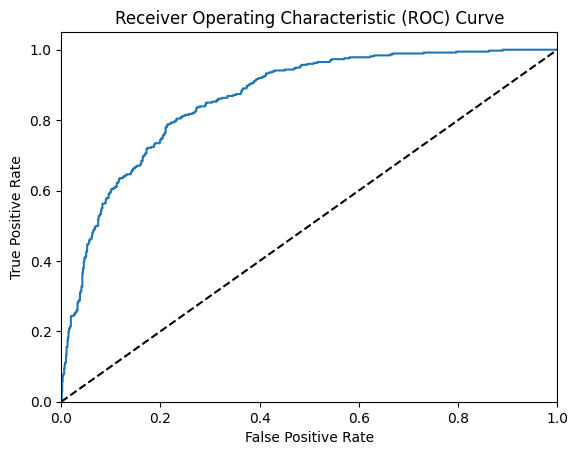

In [15]:
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')